# Speech Command Recognition: A Deep Learning Approach

## Full Code Notebook

**Autor**: Alberto Calabrese

**Mail**: alberto.calabrese.2@studenti.unipd.it

**Student ID**: 2103405

# Setup

In [1]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 20.3 MB/s eta 0:00:00


In [2]:
import os
import gc
import librosa
import numpy as np
import librosa.display
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import hashlib
import tensorflow as tf
from collections import defaultdict, Counter
from keras import layers, models
import pickle
import json
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import regularizers
import time
from sklearn.preprocessing import label_binarize, MinMaxScaler
from keras.saving import register_keras_serializable
from sklearn.manifold import TSNE
from PIL import ImageFont
import visualkeras
from IPython.display import display, Image 

2025-08-20 06:33:52.666899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755671632.867489      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755671632.964134      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
device_name = tf.test.gpu_device_name()
if device_name:
    print(f"GPU detected: {device_name}")
else:
    print("GPU not found. Go to Runtime > Change runtime type > GPU")

GPU detected: /device:GPU:0


I0000 00:00:1755671648.907630      19 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
SEEDS = [42, 1999, 2025]

def set_seeds(seed_value):
    tf.random.set_seed(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

In [5]:
''' 
Change this controller based on the dataset that is loaded in kaggle 
    If is loaded the dataset preprocessed locally (>1GB) set it to False
    If is loaded the original dataset (>2GB) set it to True to preprocess the data in the notebook

I reated this mechanism to save GPU hours
'''
FULL_DATASET = True

In [6]:
if FULL_DATASET:
    BASE_PATH = "/kaggle/input/speech-commands-v0-02/speech_commands_v0.02"
    PROCESSED_DATA_DIR = "/kaggle/working/processed_dataset"
else:
    BASE_PATH = "/kaggle/input/speechcommanddataset"
    PROCESSED_DATA_DIR = "/kaggle/input/speechcommanddataset/processed_dataset"
    
OUTPUT_DATA_DIR = "/kaggle/working"

# Data Preprocessing

In [7]:
MAX_NUM_WAVS_PER_CLASS = 2**27 - 1  # ~134M

def which_set(filename, validation_percentage, testing_percentage):
    """
    Determines which dataset partition a file should belong to.
    This function follows the indications of the dataset creators.
    Args:
    filename: File path of the data sample.
    validation_percentage: How much of the data set to use for validation.
    testing_percentage: How much of the data set to use for testing.

    Returns:
    String, one of 'training', 'validation', or 'testing'.
    """
    base_name = os.path.basename(filename)
    hash_name = re.sub(r'_nohash_.*$', '', base_name)
    hash_name_hashed = hashlib.sha1(hash_name.encode()).hexdigest()
    percentage_hash = ((int(hash_name_hashed, 16) %
                        (MAX_NUM_WAVS_PER_CLASS + 1)) *
                        (100.0 / MAX_NUM_WAVS_PER_CLASS))
    if percentage_hash < validation_percentage:
        result = 'val'
    elif percentage_hash < (testing_percentage + validation_percentage):
        result = 'test'
    else:
        result = 'train'
    return result

In [8]:
class SpeechPreprocessor:
    def __init__(self, dataset_path, output_path= PROCESSED_DATA_DIR,
                 sample_rate=16000, n_mels=40, frame_size=0.025, frame_step=0.010,
                 noise_prob=0.3):
        """
        Initializes the SpeechPreprocessor class.

        Args:
            dataset_path (str): Path to the dataset folder.
            output_path (str): Path to the output folder.
            sample_rate (int): Sampling rate of the audio files.
            n_mels (int): Number of Mel bands to generate.
            frame_size (float): Size of the frame window in seconds.
            frame_step (float): Size of the frame step in seconds.
        """
        self.dataset_path = dataset_path
        self.output_path = output_path
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.frame_size = frame_size
        self.frame_step = frame_step
        self.noise_prob = noise_prob
        self.noise_samples = self._load_noise_samples()

        # Ensure output directories exist
        os.makedirs(self.output_path, exist_ok=True)
        for split in ["train", "val", "test"]:
            os.makedirs(f"{self.output_path}/{split}", exist_ok=True)
        print(f"Initialized SpeechPreprocessor with dataset path: {self.dataset_path} and output path: {self.output_path}")

    def _load_noise_samples(self):
        """
        Loads background noise samples from the dataset.
        Returns:
            list: List of noise samples.
        """
        noise_dir = os.path.join(self.dataset_path, "_background_noise_")
        noises = []
        for fname in os.listdir(noise_dir):
            if fname.endswith(".wav"):
                noise_path = os.path.join(noise_dir, fname)
                y, _ = librosa.load(noise_path, sr=self.sample_rate)
                noises.append(y)
        return noises

    def _time_shift(self, audio, shift_max=0.1):
        """
        Applies a random time shift to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to be shifted.
            shift_max (float): Maximum shift in seconds.
        Returns:
            np.ndarray: Time-shifted audio signal.
        """
        shift = int(random.uniform(-shift_max, shift_max) * self.sample_rate)
        if shift > 0:
            audio = np.pad(audio, (shift, 0), mode='constant')[:len(audio)]
        elif shift < 0:
            audio = np.pad(audio, (0, -shift), mode='constant')[-shift:]
        return audio

    def _spec_augment(self, spectrogram, freq_mask_param=3, time_mask_param=8):
        """
        Applies SpecAugment to the spectrogram.
        Args:
            spectrogram (np.ndarray): Input spectrogram.
            freq_mask_param (int): Maximum frequency mask size.
            time_mask_param (int): Maximum time mask size.
        Returns:
            np.ndarray: Augmented spectrogram.
        """
        spec = np.copy(spectrogram)
        num_mel_channels = spec.shape[0]
        num_time_steps = spec.shape[1]

        # Frequency masking
        for _ in range(1):
            f = random.randint(0, freq_mask_param)
            f0 = random.randint(0, num_mel_channels - f)
            spec[f0:f0 + f, :] = 0

        # Time masking
        for _ in range(1):
            t = random.randint(0, time_mask_param)
            t0 = random.randint(0, num_time_steps - t)
            spec[:, t0:t0 + t] = 0

        return spec

    def _add_noise(self, audio):
        """
        Adds random background noise to the audio signal.
        Args:
            audio (np.ndarray): Audio signal to which noise will be added.
        Returns:
            np.ndarray: Audio signal with added noise.
        """
        # If no noise samples are loaded or noise probability is not met, return original audio
        if not self.noise_samples or random.random() > self.noise_prob:
            return audio

        noise = random.choice(self.noise_samples)
        if len(noise) > len(audio):
            start_idx = random.randint(0, len(noise) - len(audio))
            noise = noise[start_idx:start_idx + len(audio)]
        else:
            noise = np.pad(noise, (0, len(audio) - len(noise)))

        # Random noise level between 0.1x and 0.4x of audio signal
        noise_level = random.uniform(0.1, 0.4)
        return audio + noise_level * noise

    def _get_spectrogram(self, filepath, add_noise=False, apply_time_shift=False, apply_spec_augment=False,
                        time_shift_prob=0.5, spec_augment_prob=0.5):
        """
        Converts a .wav file into a log Mel spectrogram.

        Args:
            filepath (str): Path to the .wav file.
            add_noise (bool): Whether to add background noise to the audio.

        Returns:
            np.ndarray: Log Mel spectrogram of the audio file.
        """
        y, sr = librosa.load(filepath, sr=self.sample_rate)

        if apply_time_shift and random.random() < time_shift_prob:
            y = self._time_shift(y)

        if add_noise:
            y = self._add_noise(y)

        spectrogram = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=self.n_mels,
            hop_length=int(self.frame_step * sr),
            n_fft=int(self.frame_size * sr)
        )
        spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

        if apply_spec_augment and random.random() < spec_augment_prob:
            spectrogram = self._spec_augment(spectrogram)

        # Pad or truncate to fixed width
        target_width = 101
        if spectrogram.shape[1] < target_width:
            spectrogram = np.pad(spectrogram, ((0, 0), (0, target_width - spectrogram.shape[1])), mode="constant")
        else:
            spectrogram = spectrogram[:, :target_width]

        return spectrogram


    def process_audio_files(self):
        """
        Processes all audio files and applies dataset partitioning.
        Data augmentation is applied only to the training set.
        """
        print("Processing audio files...")

        noise_count = 0
        time_shift_count = 0
        spec_augment_count = 0

        for label in tqdm(os.listdir(self.dataset_path)):
            label_path = os.path.join(self.dataset_path, label)
            # Skip if the path is not a directory or the label is _background_noise_
            if not os.path.isdir(label_path) or label == "_background_noise_":
                continue

            for filename in os.listdir(label_path):
                if not filename.endswith(".wav"):
                    continue

                filepath = os.path.join(label_path, filename)

                # Determine dataset partition
                dataset_type = which_set(filename, 10, 10)

                # Add noise only for training set
                is_train = (dataset_type == "train")

                # Check if the spectrogram is already saved
                output_dir = os.path.join(self.output_path, dataset_type, label)
                os.makedirs(output_dir, exist_ok=True)

                output_file = os.path.join(output_dir, filename.replace(".wav", ".npy"))

                if os.path.exists(output_file):
                    continue  # Skip if the file already exists

                apply_noise = is_train and (random.random() < self.noise_prob)
                apply_time_shift = is_train and (random.random() < 0.3)
                apply_spec_augment = is_train and (random.random() < 0.3)

                # Convert to spectrogram
                spectrogram = self._get_spectrogram(
                    filepath, apply_noise, is_train, is_train,
                    time_shift_prob=0.3, spec_augment_prob=0.3
                )

                # Normalize
                spectrogram = (spectrogram - np.mean(spectrogram)) / np.std(spectrogram)

                # Save spectrogram
                np.save(output_file, spectrogram)

                # Log the augmented files
                if apply_noise:
                    noise_count += 1
                if apply_time_shift:
                    time_shift_count += 1
                if apply_spec_augment:
                    spec_augment_count += 1

        print("Data processing complete!")

        # Stats summary
        total_processed = sum(
            len([f for f in files if f.endswith(".npy")])
            for split in ["train", "val", "test"]
            for root, _, files in os.walk(os.path.join(self.output_path, split))
        )

        train_total = sum(
            len([f for f in files if f.endswith(".npy")])
            for root, _, files in os.walk(os.path.join(self.output_path, "train"))
        )

        if total_processed > 0:
            print(f"\nSummary of Preprocessing:")
            print(f"- Total samples processed: {total_processed}")

        if train_total > 0:
            print(f"- Total training samples: {train_total}")
            print(f"- Training samples with noise: {noise_count} ({(noise_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with time shift: {time_shift_count} ({(time_shift_count / train_total) * 100:.2f}%)")
            print(f"- Training samples with SpecAugment: {spec_augment_count} ({(spec_augment_count / train_total) * 100:.2f}%)\n")



    def visualize_random_sample(self):
        sample_class = random.choice(os.listdir(f"{self.output_path}/train"))
        sample_file = random.choice(os.listdir(f"{self.output_path}/train/{sample_class}"))

        spectrogram = np.load(f"{self.output_path}/train/{sample_class}/{sample_file}")

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram, sr=self.sample_rate,
                                 hop_length=int(self.frame_step * self.sample_rate),
                                 x_axis="time", y_axis="mel")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram of {sample_file}")
        plt.show()

Initialized SpeechPreprocessor with dataset path: /kaggle/input/speech-commands-v0-02/speech_commands_v0.02 and output path: /kaggle/working/processed_dataset
Processing audio files...


100%|██████████| 40/40 [23:49<00:00, 35.74s/it]


Data processing complete!

Summary of Preprocessing:
- Total samples processed: 105829
- Total training samples: 84843
- Training samples with noise: 25395 (29.93%)
- Training samples with time shift: 25491 (30.04%)
- Training samples with SpecAugment: 25455 (30.00%)



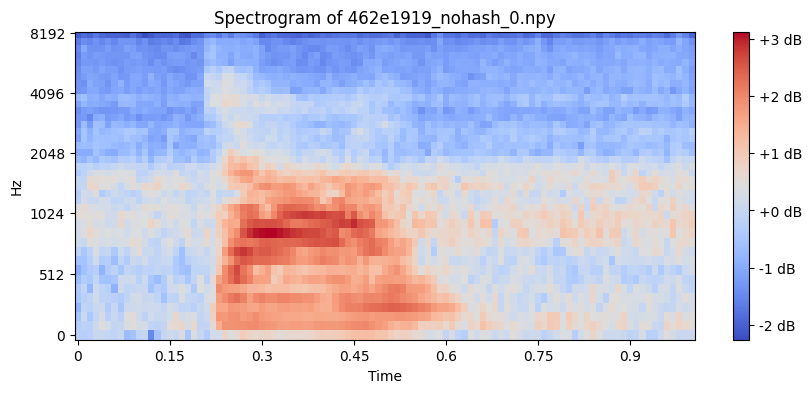

In [9]:
def preprocess():
    # Create the preprocessor instance
    processor = SpeechPreprocessor(BASE_PATH)

    # Process all audio files
    processor.process_audio_files()

    # Visualize a sample spectrogram as a sanity check
    processor.visualize_random_sample()

if FULL_DATASET:
    preprocess()

In [10]:
def get_class_weights(train_path):
    """
    Computes class weights based on the number of .wav files in each class directory.

    Args:
        train_path (str): Path to the train dataset folder.

    Returns:
        class_weights (dict): {class_index: weight}
        label_to_index (dict): {label_name: index}
        index_to_label (dict): {index: label_name}
    """
    # List class names
    class_names = sorted([
        d for d in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, d))
    ])

    label_to_index = {label: idx for idx, label in enumerate(class_names)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}

    class_counts = Counter()
    for label in class_names:
        label_dir = os.path.join(train_path, label)
        num_files = len([f for f in os.listdir(label_dir) if f.endswith(".npy")])
        class_counts[label] = num_files

    y_all = np.concatenate([[label] * class_counts[label] for label in class_names])

    weights = compute_class_weight(class_weight="balanced", classes=np.array(class_names), y=y_all)
    class_weights = {label_to_index[class_names[i]]: weights[i] for i in range(len(class_names))}

    return class_weights, label_to_index, index_to_label

train_path = PROCESSED_DATA_DIR + "/train"

class_weights, label_to_index, index_to_label = get_class_weights(train_path)

In [11]:
with open('label_to_index.json', 'w') as f:
    json.dump(label_to_index, f)

print(label_to_index)

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


# Data Loading

In [12]:
def load_dataset(split_path, label_to_index, input_shape=(40, 101), shuffle=True):
    data = []
    labels = []

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue

        for fname in os.listdir(label_path):
            if not fname.endswith(".npy"):
                continue

            file_path = os.path.join(label_path, fname)
            spectrogram = np.load(file_path).astype(np.float32)

            # Ensure shape matches
            if spectrogram.shape != input_shape:
                print(f"Skipping {file_path} due to shape mismatch: {spectrogram.shape}")
                continue

            data.append(spectrogram)
            labels.append(label_to_index[label])


    data = np.array(data)[..., np.newaxis]  # Add channel dim
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((data, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(data))

    return dataset, data, labels

In [13]:
train_ds, _, _ = load_dataset(os.path.join(PROCESSED_DATA_DIR, "train"), label_to_index)
val_ds, _, _ = load_dataset(os.path.join(PROCESSED_DATA_DIR, "val"), label_to_index, shuffle=False)
test_ds, X_test, y_test = load_dataset(os.path.join(PROCESSED_DATA_DIR, "test"), label_to_index, shuffle=False)


BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1755673104.200448      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Utils

In [14]:
def save_and_plot_results(history, model, model_name, saving_dir, transformer = False):
    """
    Save the model training history, its metadata and plots results for accuracy and loss.
    Also, visualize and save the model architecture using visualkeras with custom text.
    Args:
        history
        model
        model_name (str)
        saving_dir (str)
    """
    print(f"\n--- Saving results for model: {model_name} ---")
    
    os.makedirs(saving_dir, exist_ok=True)

    history_dict = history.history

    plt.figure(figsize=(10, 6))
    plt.plot(history_dict['loss'], label='Training Loss', marker='o')
    plt.plot(history_dict['val_loss'], label='Validation Loss', marker='o')
    plt.title(f"Loss: {model_name.replace('_', ' ').title()}", fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    loss_path = os.path.join(saving_dir, f"{model_name}_loss.png")
    plt.savefig(loss_path)
    plt.show()
    print(f"Loss plot saved to {loss_path}")

    plt.figure(figsize=(10, 6))
    plt.plot(history_dict['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f"Accuracy: {model_name.replace('_', ' ').title()}", fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    accuracy_path = os.path.join(saving_dir, f"{model_name}_accuracy.png")
    plt.savefig(accuracy_path)
    plt.show()
    print(f"Accuracy plot saved to {accuracy_path}")

    history_path = os.path.join(saving_dir, "training_history.pkl")
    with open(history_path, "wb") as f:
        pickle.dump(history_dict, f)
    print(f"Training history saved to {history_path}")

    if transformer == False: # Excluded Transformer based models and Hybrid CNN BiLSTM 
        print(f"\n--- Plotting model architecture for: {model_name} ---")
        architecture_path = os.path.join(saving_dir, f"{model_name}_architecture.png")
        architecture_path_custom = os.path.join(saving_dir, f"{model_name}_architecture_custom.png")
            
        visualkeras.layered_view(model, legend=True, to_file=architecture_path)
        visualkeras.layered_view(model, legend=True, to_file=architecture_path_custom, show_dimension=True)
        print("Model architecture plot saved")
        display(Image(filename=architecture_path_custom))

In [15]:
def get_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]

In [16]:
def train_models(model_name, model_instance, seed):
    saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
    os.makedirs(saving_dir, exist_ok=True)
    checkpoint_path = os.path.join(saving_dir, f"{model_name}_seed_{seed}_best.keras")
    metadata_path = os.path.join(saving_dir, f"metadata_{model_name}_seed_{seed}.json")

    model_instance.compile()
    model = model_instance.get_model()

    history = model.fit(
        train_ds, validation_data=val_ds, epochs=20,
        class_weight=class_weights,
        callbacks=get_callbacks(checkpoint_path)
    )

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    metadata = {
        "model_name": model_name,
        "seed": seed,
        "epochs_trained": int(best_epoch_idx + 1),
        "best_train_acc": round(float(history.history['accuracy'][best_epoch_idx]), 4),
        "best_val_acc": round(float(history.history['val_accuracy'][best_epoch_idx]), 4),
        "input_shape": list(model.input_shape),
        "output_shape": list(model.output_shape),
        "num_params": int(model.count_params())
    }
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata for seed {seed} saved to {metadata_path}")

    tf.keras.backend.clear_session()
    gc.collect()

    return history, checkpoint_path

# Models Definition and Training

## Baseline CNN

In [17]:
def baseline_cnn(input_shape=(40, 101, 1), num_classes = len(label_to_index)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    lr = 1e-3
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    loss = 'sparse_categorical_crossentropy'
    metrics = ['accuracy']
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

In [18]:
model_name = "baseline_cnn"
print(f"\nTRAINING MODEL: {model_name.upper()}")

best_seed_history = None
best_seed_val_accuracy = 0.0
best_seed_checkpoint_path = ""

for seed in SEEDS:
    set_seeds(seed)
    print(f"\n--- Training '{model_name}' with Seed: {seed} ---")

    model = baseline_cnn(input_shape=(40, 101, 1), num_classes=len(label_to_index))
    
    saving_dir = f"{OUTPUT_DATA_DIR}/{model_name}"
    os.makedirs(saving_dir, exist_ok=True)
    checkpoint_path = os.path.join(saving_dir, f"{model_name}_seed_{seed}_best.keras")
    metadata_path = os.path.join(saving_dir, f"metadata_{model_name}_seed_{seed}.json")

    history = model.fit(
        train_ds, validation_data=val_ds, epochs=20,
        class_weight=class_weights,
        callbacks=get_callbacks(checkpoint_path)
    )

    history_dict = history.history
    best_epoch_idx = np.argmax(history_dict['val_accuracy'])
    best_train_acc = history_dict['accuracy'][best_epoch_idx]
    best_val_acc = history_dict['val_accuracy'][best_epoch_idx]
    effective_epochs = best_epoch_idx + 1
    
    metadata = {
        "model_name": model_name,
        "seed": seed,
        "epochs_trained": int(effective_epochs),
        "best_train_acc": round(float(best_train_acc), 4),
        "best_val_acc": round(float(best_val_acc), 4),
        "input_shape": list(model.input_shape),
        "output_shape": list(model.output_shape),
        "num_params": int(model.count_params())
    }
    
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata for seed {seed} saved to {metadata_path}")
    
    current_best_val_acc = max(history.history['val_accuracy'])
    if current_best_val_acc > best_seed_val_accuracy:
        best_seed_val_accuracy = current_best_val_acc
        best_seed_history = history
        best_seed_checkpoint_path = checkpoint_path
        
    tf.keras.backend.clear_session()
    gc.collect()


TRAINING MODEL: BASELINE_CNN

--- Training 'baseline_cnn' with Seed: 42 ---
Epoch 1/20


I0000 00:00:1755673117.008094      73 service.cc:148] XLA service 0x7de7e4002290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755673117.008642      73 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755673117.378651      73 cuda_dnn.cc:529] Loaded cuDNN version 90300


  16/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.0275 - loss: 3.6189

I0000 00:00:1755673121.386229      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.0787 - loss: 3.3858 - val_accuracy: 0.1903 - val_loss: 2.7219 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3168 - loss: 2.3737 - val_accuracy: 0.4745 - val_loss: 1.7808 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4345 - loss: 1.9470 - val_accuracy: 0.4854 - val_loss: 1.7312 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4959 - loss: 1.7299 - val_accuracy: 0.5136 - val_loss: 1.6074 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5280 - loss: 1.6170 - val_accuracy: 0.6174 - val_loss: 1.2897 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5554 - loss: 1.5245 - val_accuracy: 0.6404 - val_loss: 1.2236 - learning_rate: 0.0010
Epoch 7/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5685 

In [19]:
model = load_model(best_seed_checkpoint_path)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 99, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 99, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,723 (373.92 KB)

 Trainable params: 31,843 (124.39 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 63,688 (248.79 KB)

In [20]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7667 - loss: 0.8012
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7466 - loss: 0.8531

Validation accuracy: 0.7769
Validation loss: 0.7563

Test accuracy: 0.7641
Test loss: 0.7815



--- Saving results for model: baseline_cnn ---


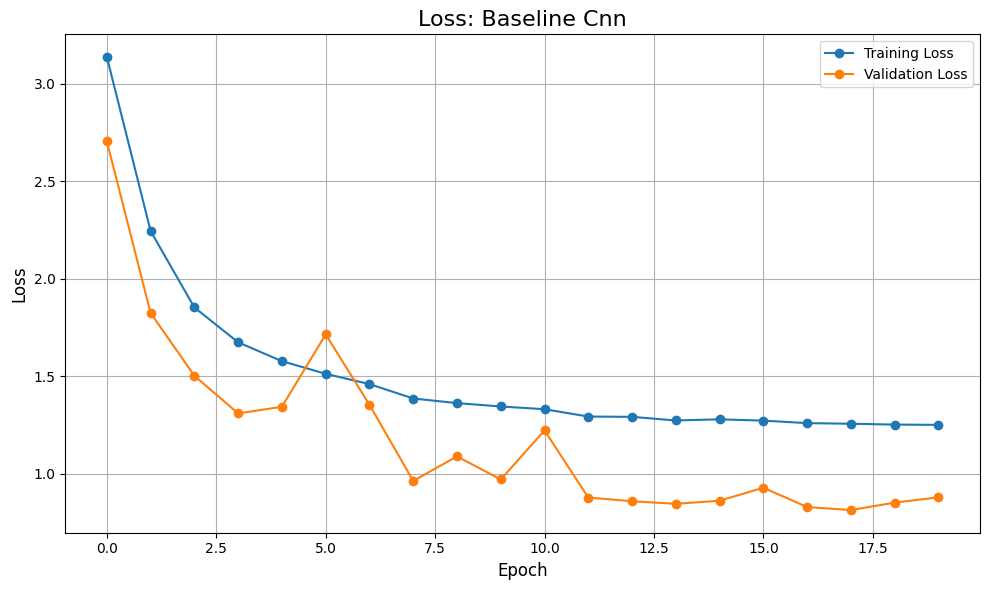

Loss plot saved to /kaggle/working/baseline_cnn/baseline_cnn_loss.png


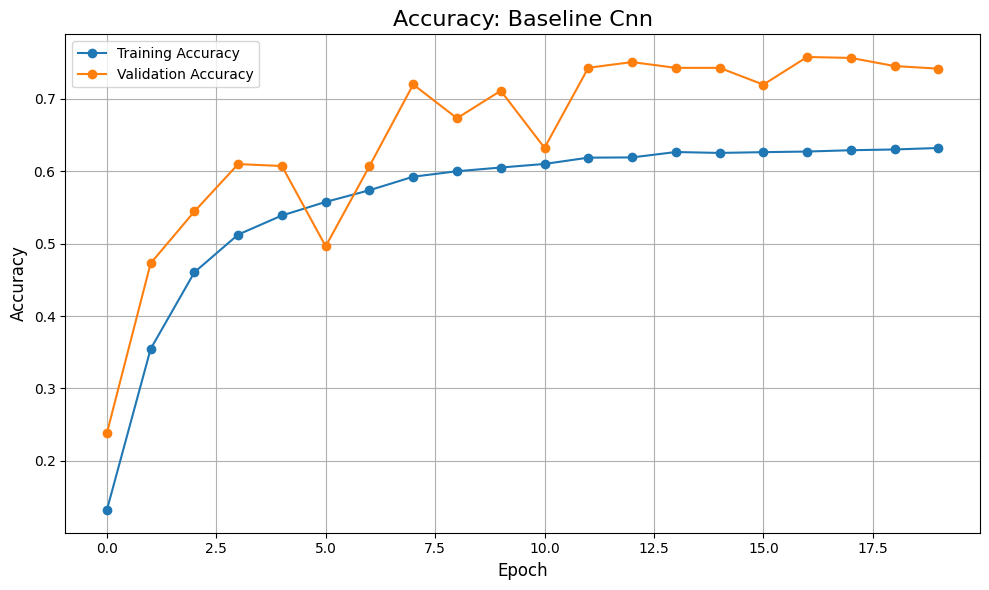

Accuracy plot saved to /kaggle/working/baseline_cnn/baseline_cnn_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl

--- Plotting model architecture for: baseline_cnn ---
Model architecture plot saved


/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


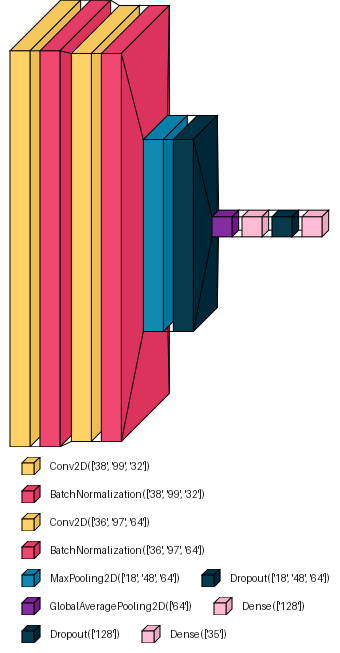

In [21]:
save_and_plot_results(history, model, model_name, saving_dir)

## Residual CNN (ResNet)

In [22]:
class ResidualCNN:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index)):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        shortcut = x

        # First convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Second convolutional layer
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)

        # Shortcut connection
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # Residual blocks
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        x = self._res_block(x, 128, stride=2)

        x = layers.GlobalAveragePooling2D(name="feature_embedding")(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs, outputs)
        return model

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [23]:
model_name = "residual_cnn"
print(f"\n{'='*20} TRAINING MODEL: {model_name.upper()}")

best_seed_history = None
best_seed_val_accuracy = 0.0
best_seed_checkpoint_path = ""

for seed in SEEDS:
    set_seeds(seed)
    print(f"\n--- Training '{model_name}' with Seed: {seed} ---")

    model_instance = ResidualCNN(input_shape=(40, 101, 1), num_classes=len(label_to_index))
    history, checkpoint_path = train_models(model_name, model_instance, seed)

    current_best_val_acc = max(history.history['val_accuracy'])
    if current_best_val_acc > best_seed_val_accuracy:
        best_seed_val_accuracy = current_best_val_acc
        best_seed_history = history
        best_seed_checkpoint_path = checkpoint_path


==================== TRAINING MODEL: RESIDUAL_CNN

--- Training 'residual_cnn' with Seed: 42 ---
Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.2672 - loss: 2.6983 - val_accuracy: 0.6506 - val_loss: 1.2056 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.7628 - loss: 0.8695 - val_accuracy: 0.8564 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.8305 - loss: 0.6034 - val_accuracy: 0.7652 - val_loss: 0.8574 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.8575 - loss: 0.5023 - val_accuracy: 0.8968 - val_loss: 0.3522 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.8763 - loss: 0.4317 - val_accuracy: 0.9263 - val_loss: 0.2525 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.8884 - loss: 0.3920 - val_accuracy: 0.9377 - val_los

In [24]:
best_model = load_model(best_seed_checkpoint_path)

best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 101,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 40, 101,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 40, 101,   │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 51,    │     18,496 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 51,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 51,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_4[0][0]  

 Total params: 937,259 (3.58 MB)

 Trainable params: 311,971 (1.19 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 623,944 (2.38 MB)

In [25]:
val_loss, val_acc = best_model.evaluate(val_ds)

test_loss, test_acc = best_model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9574 - loss: 0.1607
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9533 - loss: 0.1634

Validation accuracy: 0.9567
Validation loss: 0.1579

Test accuracy: 0.9518
Test loss: 0.1609



--- Saving results for model: residual_cnn ---


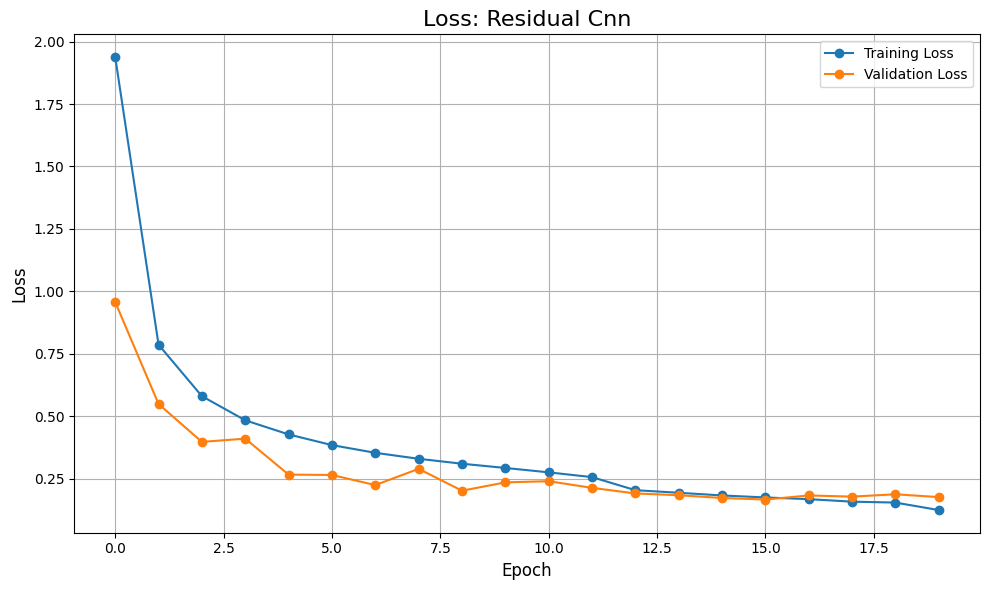

Loss plot saved to /kaggle/working/baseline_cnn/residual_cnn_loss.png


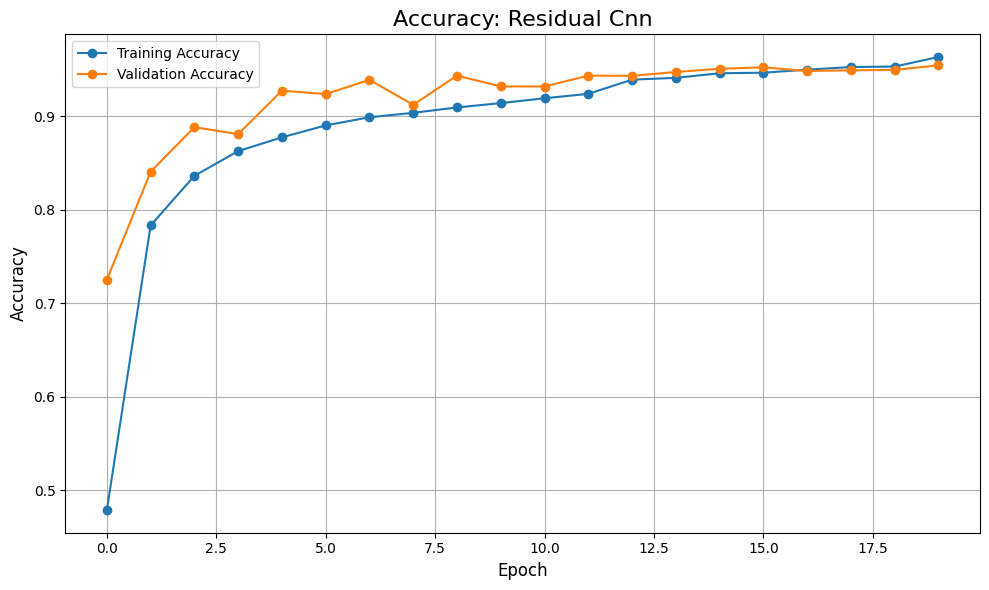

Accuracy plot saved to /kaggle/working/baseline_cnn/residual_cnn_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl

--- Plotting model architecture for: residual_cnn ---
Model architecture plot saved


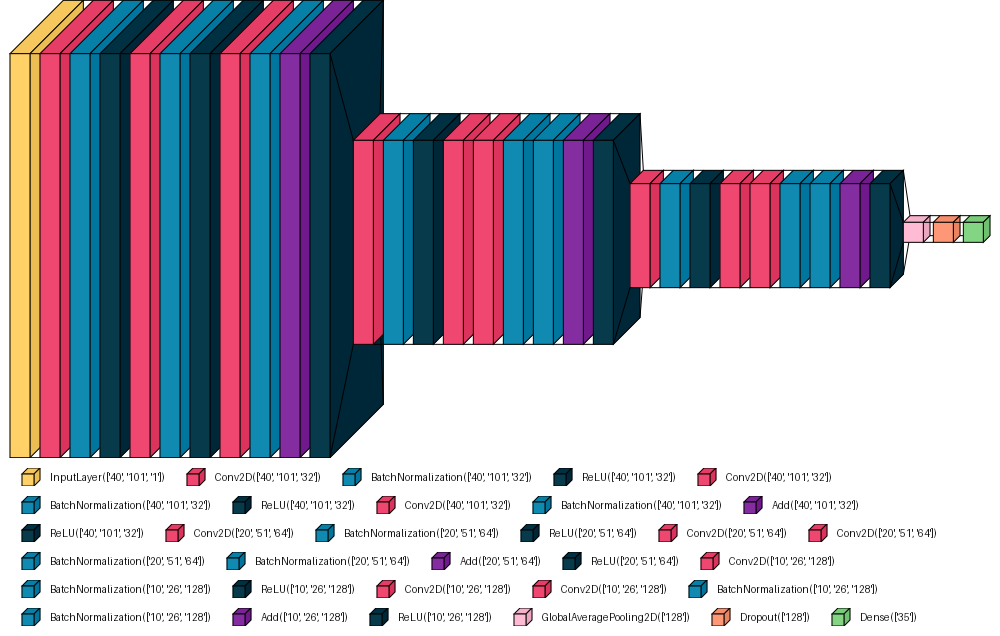

In [26]:
save_and_plot_results(history, best_model, model_name, saving_dir)

## Hybrid CNN + BiLSTM

Hybrid model that combines a CNN frontend with a BiLSTM backend.

In [27]:
class CNNBiLSTMModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=12,
                 lstm_units=32, dense_units=64, dropout_rate=0.3):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = tf.keras.Input(shape=self.input_shape)

        # CNN Layers
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x) 

        # Reshape
        x = layers.Permute((2, 1, 3))(x)
        current_shape = x.shape
        x = layers.Reshape((current_shape[1], current_shape[2] * current_shape[3]))(x)

        # Feature Compression
        x = layers.TimeDistributed(layers.Dense(128, activation='relu'))(x)

        # BiLSTM with return_sequences
        x = layers.Bidirectional(
            layers.LSTM(self.lstm_units, return_sequences=True)
        )(x)

        # Pooling across time
        x = layers.GlobalAveragePooling1D()(x)

        # Dropout + Classifier
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.dense_units, activation='relu', name="feature_embedding")(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs, outputs)

    def compile(self, learning_rate=0.001):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    def get_model(self):
        return self.model

In [28]:
model_name = "hybrid_cnn_bilstm"
print(f"\nTRAINING MODEL: {model_name.upper()}")

best_seed_history = None
best_seed_val_accuracy = 0.0
best_seed_checkpoint_path = ""

for seed in SEEDS:
    set_seeds(seed)
    print(f"\n--- Training '{model_name}' with Seed: {seed} ---")

    model_instance = CNNBiLSTMModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))
    history, checkpoint_path = train_models(model_name, model_instance, seed)

    current_best_val_acc = max(history.history['val_accuracy'])
    if current_best_val_acc > best_seed_val_accuracy:
        best_seed_val_accuracy = current_best_val_acc
        best_seed_history = history
        best_seed_checkpoint_path = checkpoint_path


TRAINING MODEL: HYBRID_CNN_BILSTM

--- Training 'hybrid_cnn_bilstm' with Seed: 42 ---
Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.2604 - loss: 2.6575 - val_accuracy: 0.7462 - val_loss: 0.8889 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.7197 - loss: 0.9662 - val_accuracy: 0.8777 - val_loss: 0.4174 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8074 - loss: 0.6735 - val_accuracy: 0.9101 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8441 - loss: 0.5432 - val_accuracy: 0.9220 - val_loss: 0.2667 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8649 - loss: 0.4705 - val_accuracy: 0.9272 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8809 - loss: 0.4140 - val_accuracy: 0.9232 - val_loss: 0.2684 -

In [29]:
best_model = load_model(best_seed_checkpoint_path)

best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 101, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 101, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 25, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 25, 128)        │        82,048 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_embedding (Dense)       │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,315 (1.70 MB)

 Trainable params: 148,707 (580.89 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 297,416 (1.13 MB)

In [30]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7667 - loss: 0.8012
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7466 - loss: 0.8531

Validation accuracy: 0.7769
Validation loss: 0.7563

Test accuracy: 0.7641
Test loss: 0.7815



--- Saving results for model: hybrid_cnn_bilstm ---


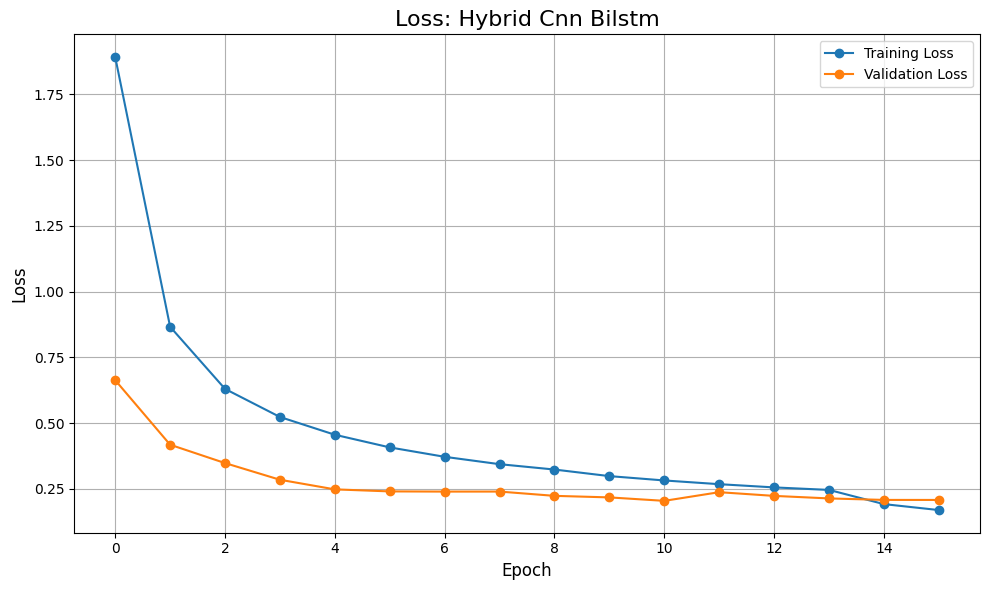

Loss plot saved to /kaggle/working/baseline_cnn/hybrid_cnn_bilstm_loss.png


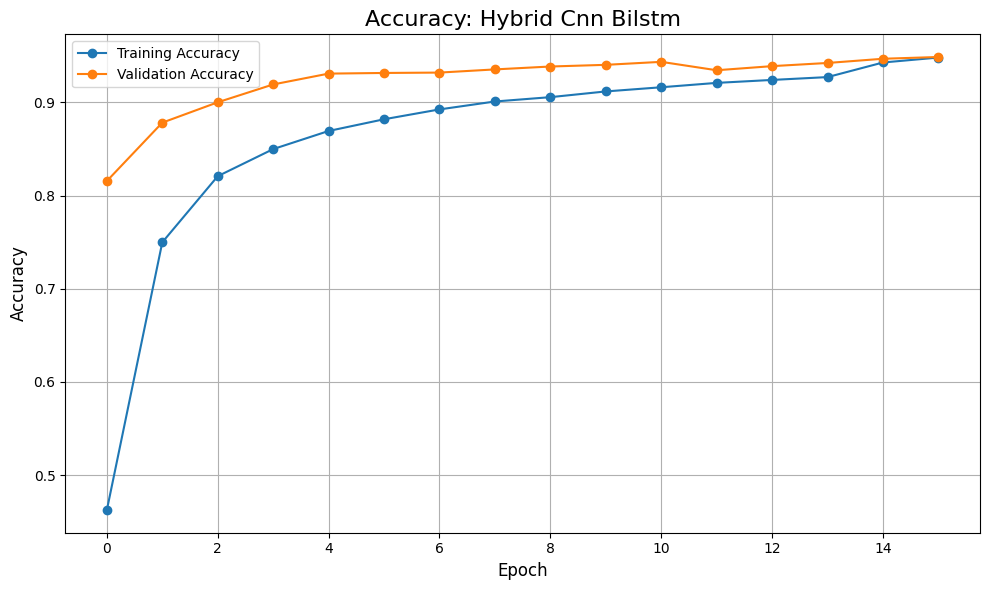

Accuracy plot saved to /kaggle/working/baseline_cnn/hybrid_cnn_bilstm_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl


In [31]:
save_and_plot_results(history, model, model_name, saving_dir, transformer = True)

## Hybrid CNN + Transformer

Hybrid model that combines a CNN frontend with a Transformer backend.

In [32]:
def transformer_encoder_block(embed_dim, num_heads, ff_dim, dropout_rate=0.1):
    inputs = layers.Input(shape=(None, embed_dim))
    
    # Multi-Head Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim
    )(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    # Feed-Forward Network
    ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    
    return models.Model(inputs=inputs, outputs=out2)

@register_keras_serializable()
class PositionalEncoding(layers.Layer):
    def __init__(self, max_steps, max_dims, **kwargs):
        super().__init__(**kwargs)
        self.max_steps = max_steps
        self.max_dims = max_dims
        self.positional_encoding = self.build_pe(max_steps, max_dims)

    def build_pe(self, max_steps, max_dims):
        pe = np.zeros((max_steps, max_dims))
        position = np.arange(0, max_steps, dtype=np.float32).reshape(-1, 1)
        div_term = np.exp(np.arange(0, max_dims, 2, dtype=np.float32) * -(np.log(10000.0) / max_dims))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        return tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_steps": self.max_steps,
            "max_dims": self.max_dims,
        })
        return config

In [33]:
class HybridCNNTransformerModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 num_transformer_blocks=2, embed_dim=64, num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.num_transformer_blocks = num_transformer_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)

        # Convolutional Feature Extractor
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Reshape to a sequence
        x = layers.Permute((2, 1, 3))(x)

        x = layers.Reshape((x.shape[1], -1))(x)
        
        # Project to the Transformer's embedding dimension
        x = layers.Dense(self.embed_dim)(x)
        
        # Add Positional Encoding
        x = PositionalEncoding(max_steps=x.shape[1], max_dims=self.embed_dim)(x)

        # Transformer Encoder Blocks
        for _ in range(self.num_transformer_blocks):
            encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
            x = encoder(x)
        
        # Classifier Head
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.ff_dim, activation='relu', name="feature_embedding")(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [34]:
model_name = "hybrid_cnn_transformer"
print(f"\nTRAINING MODEL: {model_name.upper()}")

best_seed_history = None
best_seed_val_accuracy = 0.0
best_seed_checkpoint_path = ""

for seed in SEEDS:
    set_seeds(seed)
    print(f"\n--- Training '{model_name}' with Seed: {seed} ---")

    model_instance = HybridCNNTransformerModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))
    history, checkpoint_path = train_models(model_name, model_instance, seed)

    current_best_val_acc = max(history.history['val_accuracy'])
    if current_best_val_acc > best_seed_val_accuracy:
        best_seed_val_accuracy = current_best_val_acc
        best_seed_history = history
        best_seed_checkpoint_path = checkpoint_path


TRAINING MODEL: HYBRID_CNN_TRANSFORMER

--- Training 'hybrid_cnn_transformer' with Seed: 42 ---
Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.3423 - loss: 2.3390 - val_accuracy: 0.8236 - val_loss: 0.5881 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7483 - loss: 0.8647 - val_accuracy: 0.8477 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7838 - loss: 0.7500 - val_accuracy: 0.8553 - val_loss: 0.4779 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8026 - loss: 0.6819 - val_accuracy: 0.8971 - val_loss: 0.3520 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8197 - loss: 0.6242 - val_accuracy: 0.8769 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8220 - loss: 0.6190 - val_accuracy: 0.9054 - val_loss

In [35]:
best_model = load_model(best_seed_checkpoint_path)

best_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 101, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 101, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 25, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 25, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 25, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 25, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_embedding (Dense)       │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,259 (2.48 MB)

 Trainable params: 216,355 (845.14 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 432,712 (1.65 MB)

In [36]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7667 - loss: 0.8012
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7466 - loss: 0.8531

Validation accuracy: 0.7769
Validation loss: 0.7563

Test accuracy: 0.7641
Test loss: 0.7815



--- Saving results for model: hybrid_cnn_transformer ---


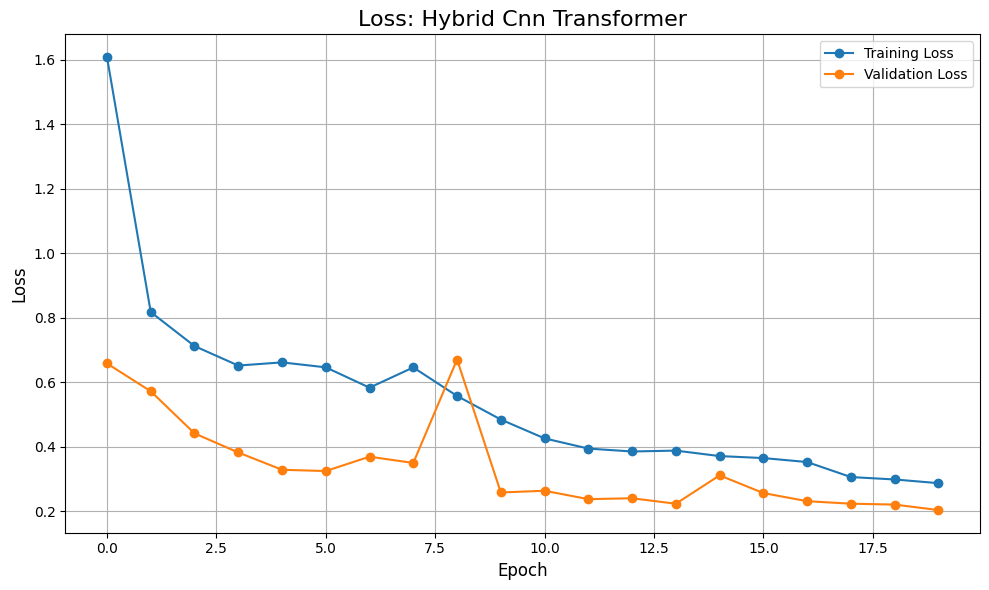

Loss plot saved to /kaggle/working/baseline_cnn/hybrid_cnn_transformer_loss.png


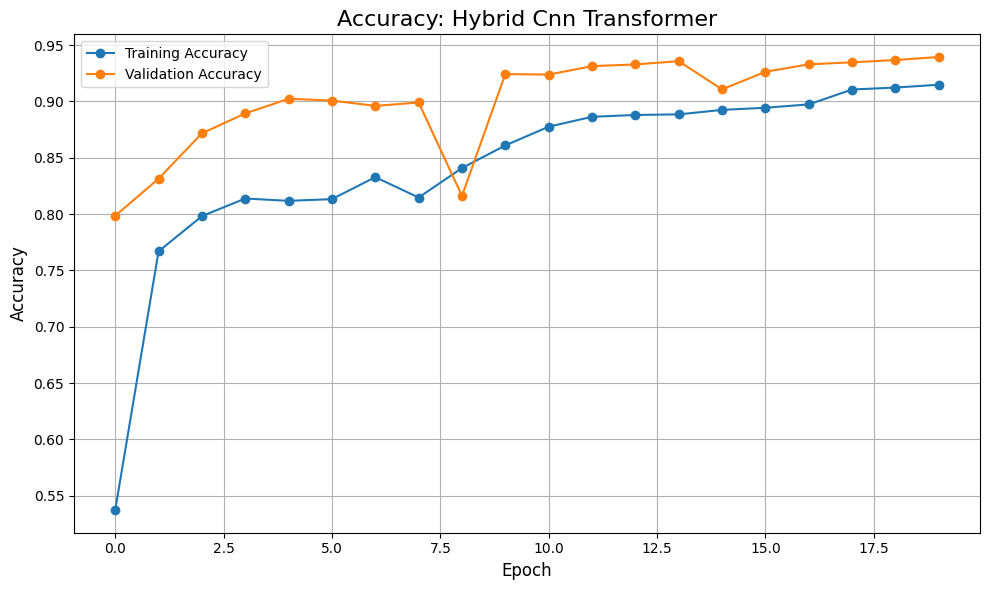

Accuracy plot saved to /kaggle/working/baseline_cnn/hybrid_cnn_transformer_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl


In [37]:
save_and_plot_results(history, model, model_name, saving_dir, transformer = True)

## Vision Transformer (ViT)

In [38]:
@register_keras_serializable()
class Patches(layers.Layer):
    """Splits an image into patches."""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config
    

@register_keras_serializable()
class PatchEncoder(layers.Layer):
    """Encodes patches with a projection and positional embedding."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        
    def build(self, input_shape):
        self.projection = layers.Dense(units=self.embed_dim)
        self.positional_embedding = layers.Embedding(
            input_dim=self.num_patches, output_dim=self.embed_dim
        )
        super().build(input_shape)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.positional_embedding(positions)
        return encoded
        
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim": self.embed_dim,
        })
        return config

In [39]:
class VisionTransformerModel:
    def __init__(self, input_shape=(40, 101, 1), num_classes=len(label_to_index),
                 patch_size=8, num_transformer_blocks=2, embed_dim=64, 
                 num_heads=4, ff_dim=64, dropout_rate=0.2):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.num_transformer_blocks = num_transformer_blocks
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        
        # Since the input dimensions (40, 101) are not perfectly divisible by patch_size,
        # we first resize to a divisible dimension, e.g., (40, 104) -> divisible by 8
        # Note: 101 is prime, so padding/resizing is needed. I choose 104 as new size.
        resized_input = layers.Resizing(height=40, width=104)(inputs)
        
        # Create Patches
        num_patches = (40 // self.patch_size) * (104 // self.patch_size)
        patches = Patches(self.patch_size)(resized_input)

        # Encode Patches with positional embedding
        encoded_patches = PatchEncoder(num_patches, self.embed_dim)(patches)

        # Transformer Encoder Blocks
        x = encoded_patches
        for _ in range(self.num_transformer_blocks):
            encoder = transformer_encoder_block(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
            x = encoder(x)
            
        # Classifier Head
        # Global average pooling over the sequence of patches
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(self.ff_dim, activation='relu', name="feature_embedding")(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(self.num_classes, activation="softmax")(x)

        return models.Model(inputs=inputs, outputs=outputs)
    
    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [40]:
model_name = "vision_transformer"
print(f"\nTRAINING MODEL: {model_name.upper()}")

best_seed_history = None
best_seed_val_accuracy = 0.0
best_seed_checkpoint_path = ""

for seed in SEEDS:
    set_seeds(seed)
    print(f"\n--- Training '{model_name}' with Seed: {seed} ---")

    model_instance = VisionTransformerModel(input_shape=(40, 101, 1), num_classes=len(label_to_index))
    history, checkpoint_path = train_models(model_name, model_instance, seed)

    current_best_val_acc = max(history.history['val_accuracy'])
    if current_best_val_acc > best_seed_val_accuracy:
        best_seed_val_accuracy = current_best_val_acc
        best_seed_history = history
        best_seed_checkpoint_path = checkpoint_path


TRAINING MODEL: VISION_TRANSFORMER

--- Training 'vision_transformer' with Seed: 42 ---
Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.0766 - loss: 3.3622 - val_accuracy: 0.3738 - val_loss: 2.1141 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3342 - loss: 2.2651 - val_accuracy: 0.6104 - val_loss: 1.2824 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5010 - loss: 1.7139 - val_accuracy: 0.6961 - val_loss: 0.9844 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5826 - loss: 1.4310 - val_accuracy: 0.7466 - val_loss: 0.8284 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6268 - loss: 1.2709 - val_accuracy: 0.7636 - val_loss: 0.7597 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6532 - loss: 1.1645 - val_accuracy: 0.8025 - val_loss: 0.6490 - le

In [41]:
best_model = load_model(best_seed_checkpoint_path)

best_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 101, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 40, 104, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches (Patches)               │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder (PatchEncoder)    │ (None, 65, 64)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 65, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 65, 64)         │        74,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_embedding (Dense)       │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,931 (1.88 MB)

 Trainable params: 164,643 (643.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 329,288 (1.26 MB)

In [42]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7667 - loss: 0.8012
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7466 - loss: 0.8531

Validation accuracy: 0.7769
Validation loss: 0.7563

Test accuracy: 0.7641
Test loss: 0.7815



--- Saving results for model: vision_transformer ---


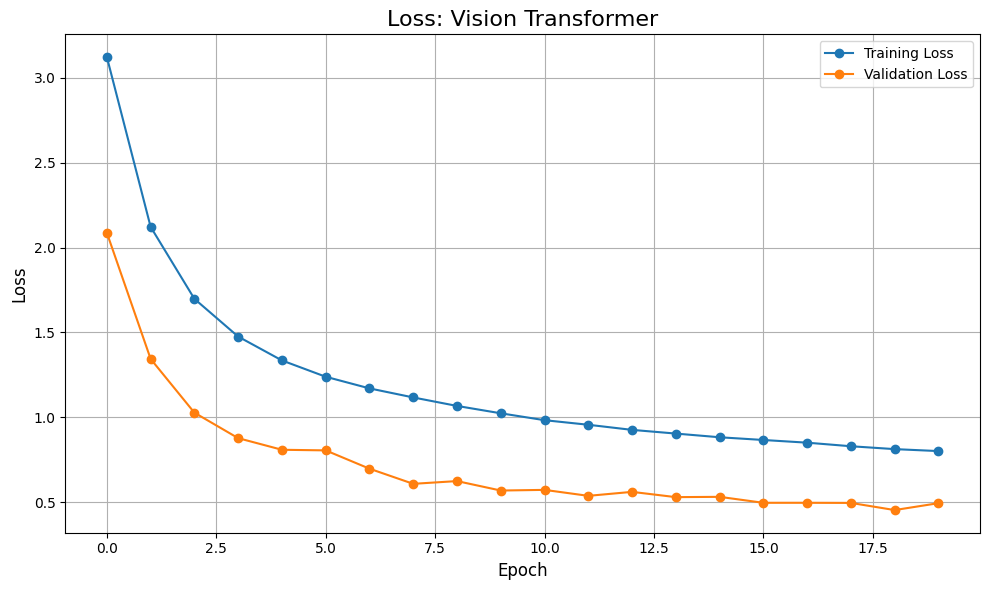

Loss plot saved to /kaggle/working/baseline_cnn/vision_transformer_loss.png


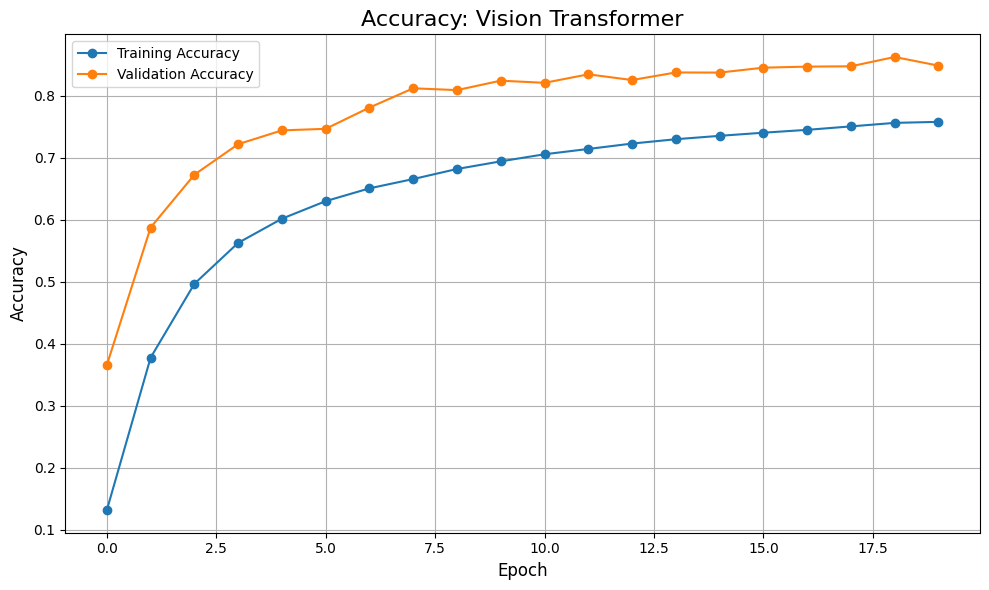

Accuracy plot saved to /kaggle/working/baseline_cnn/vision_transformer_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl


In [43]:
save_and_plot_results(history, model, model_name, saving_dir, transformer = True)

## Experimental model

### **GAN-Inspired Residual Network with Channel-wise Attention**

Experimental model architecure that combines three different Deep Learning domains:
1.  A **ResNet backbone** for robust, hierarchical feature extraction.
2.  A **Squeeze-and-Excitation (SE)** block for dynamic, channel-wise feature recalibration.
3.  A **classifier inspired by GAN discriminators**, designed to learn a highly robust decision function.

In [44]:
def squeeze_excite_block(input_tensor, ratio=8):
    """Squeeze-and-Excitation block"""
    init = input_tensor
    channel_axis = -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Reshape(se_shape)(se)
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    x = layers.multiply([init, se])
    return x

In [45]:
class ResidualGAN:
    def __init__(self, input_shape=(40, 101, 1), num_classes=label_to_index,
                 dropout_rate=0.4):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.model = self._build_model()

    def _res_block(self, x, filters, stride=1):
        """ Same residual block as the Residual CNN Model"""
        shortcut = x
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)
        if stride != 1 or shortcut.shape[-1] != filters:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.add([x, shortcut])
        x = layers.ReLU()(x)
        return x

    def _build_model(self):
        inputs = layers.Input(shape=self.input_shape)
        l2_rate = 1e-4

        # Feature Extractor (based on Residual CNN)
        x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        
        x = self._res_block(x, 32)
        x = self._res_block(x, 64, stride=2)
        feature_map = self._res_block(x, 128, stride=2)

        # Attention Block
        attention_map = squeeze_excite_block(feature_map)

        # Discriminator-style Classifier
        x = layers.Conv2D(128, kernel_size=3, strides=2, padding='same',
                          kernel_regularizer=regularizers.l2(l2_rate))(attention_map)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(self.dropout_rate)(x)

        x = layers.Conv2D(256, kernel_size=3, strides=2, padding='same',
                          kernel_regularizer=regularizers.l2(l2_rate))(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(self.dropout_rate)(x)

        x = layers.GlobalAveragePooling2D(name="feature_embedding")(x)
        
        outputs = layers.Dense(self.num_classes, activation='softmax',
                               kernel_regularizer=regularizers.l2(l2_rate))(x)

        return models.Model(inputs=inputs, outputs=outputs)

    def compile(self, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def get_model(self):
        return self.model

In [46]:
model_name = "residual_attention_gan"
print(f"\nTRAINING MODEL: {model_name.upper()}")

best_seed_history = None
best_seed_val_accuracy = 0.0
best_seed_checkpoint_path = ""

for seed in SEEDS:
    set_seeds(seed)
    print(f"\n--- Training '{model_name}' with Seed: {seed} ---")

    model_instance = ResidualGAN(input_shape=(40, 101, 1), num_classes=len(label_to_index))
    history, checkpoint_path = train_models(model_name, model_instance, seed)

    current_best_val_acc = max(history.history['val_accuracy'])
    if current_best_val_acc > best_seed_val_accuracy:
        best_seed_val_accuracy = current_best_val_acc
        best_seed_history = history
        best_seed_checkpoint_path = checkpoint_path


TRAINING MODEL: RESIDUAL_ATTENTION_GAN

--- Training 'residual_attention_gan' with Seed: 42 ---
Epoch 1/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 58s 32ms/step - accuracy: 0.4555 - loss: 1.9508 - val_accuracy: 0.8271 - val_loss: 0.6349 - learning_rate: 0.0010
Epoch 2/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.8444 - loss: 0.6060 - val_accuracy: 0.8722 - val_loss: 0.5339 - learning_rate: 0.0010
Epoch 3/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.8809 - loss: 0.4910 - val_accuracy: 0.9077 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 4/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.9011 - loss: 0.4324 - val_accuracy: 0.9314 - val_loss: 0.3275 - learning_rate: 0.0010
Epoch 5/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.9118 - loss: 0.3951 - val_accuracy: 0.9280 - val_loss: 0.3520 - learning_rate: 0.0010
Epoch 6/20
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.9197 - loss: 0.3748 - val_accuracy: 0.9466 - val_loss

In [47]:
best_model = load_model(best_seed_checkpoint_path)

best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 101,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 101,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 40, 101,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 101,   │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 101,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 101,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 40, 101,   │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 51,    │     18,496 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 20, 51,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 51,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 51,    │      2,112 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 51,    │        256 │ conv2d_4[0][0]  

 Total params: 2,291,243 (8.74 MB)

 Trainable params: 763,299 (2.91 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 1,526,600 (5.82 MB)

In [48]:
val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print(f"\nValidation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7667 - loss: 0.8012
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7466 - loss: 0.8531

Validation accuracy: 0.7769
Validation loss: 0.7563

Test accuracy: 0.7641
Test loss: 0.7815



--- Saving results for model: residual_attention_gan ---


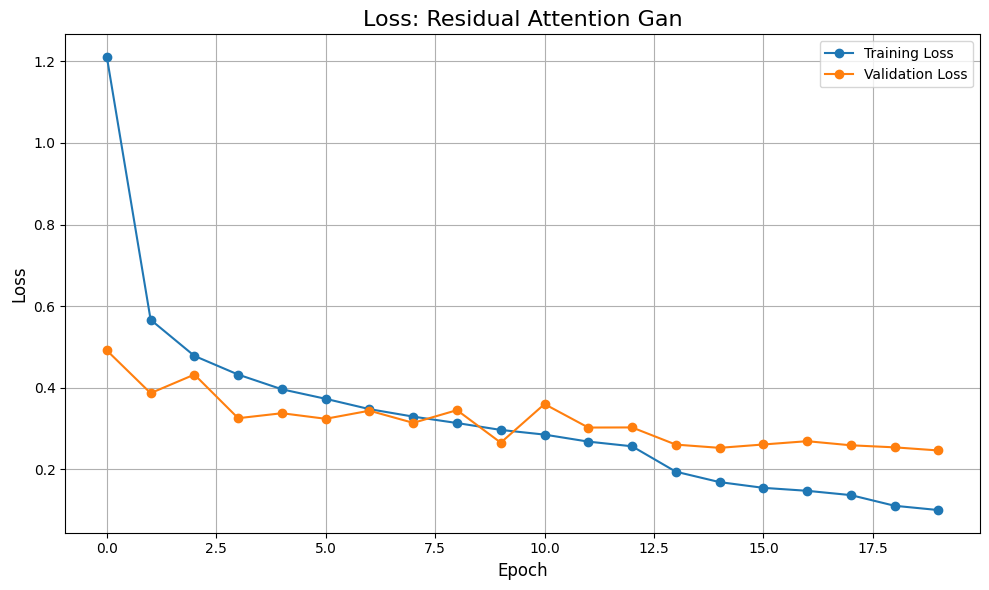

Loss plot saved to /kaggle/working/baseline_cnn/residual_attention_gan_loss.png


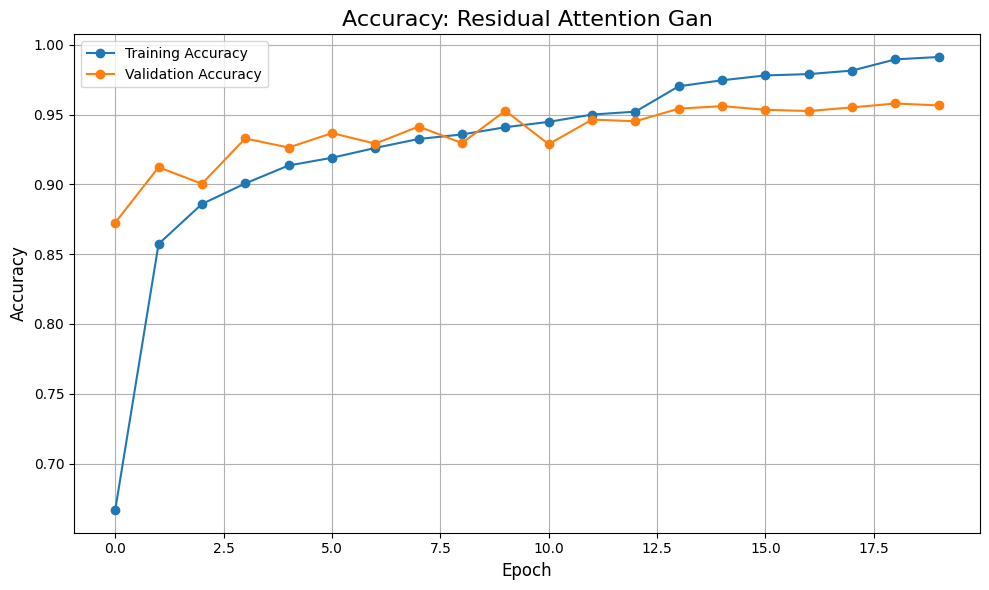

Accuracy plot saved to /kaggle/working/baseline_cnn/residual_attention_gan_accuracy.png
Training history saved to /kaggle/working/baseline_cnn/training_history.pkl

--- Plotting model architecture for: residual_attention_gan ---
Model architecture plot saved


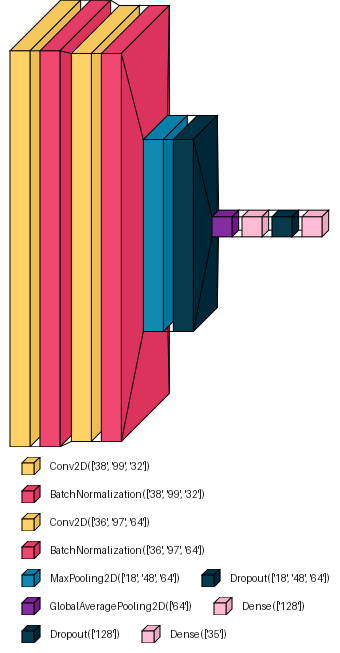

In [49]:
save_and_plot_results(history, model, model_name, saving_dir)

# Models Evaluation

In [50]:
class ModelEvaluator:
    def __init__(self, models_dir, test_data, test_labels, index_to_label, custom_objects=None, output_dir="output"):
        self.models_dir = models_dir
        self.X_test, self.y_test = test_data, test_labels
        self.index_to_label = index_to_label
        self.custom_objects = custom_objects
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.results = []
        self.df_results = None

    def _measure_inference_time(self, model, num_runs=10):
        """Evaluate the inference time of a model"""
        dummy_input = self.X_test[:1]
        _ = model.predict(dummy_input, verbose=0)
        
        start_time = time.time()
        for _ in range(num_runs):
            _ = model.predict(self.X_test, verbose=0, batch_size=64)
        end_time = time.time()
        
        avg_time_per_sample_ms = ((end_time - start_time) / num_runs / len(self.X_test)) * 1000
        return avg_time_per_sample_ms

    def _calculate_multiclass_auc(self, y_true, y_pred_proba, all_classes):
        """Computes AUC for the multi-class problem using OvR"""
        y_true_binarized = label_binarize(y_true, classes=all_classes)
        return roc_auc_score(y_true_binarized, y_pred_proba, multi_class='ovr', average='macro')

    def plot_tsne_embeddings(self, model, model_name):
        print(f"\n--- Generating T-SNE plot for {model_name} ---")
        
        try:
            feature_layer = model.get_layer(name="feature_embedding")
        except ValueError:
            print("Warning: 'feature_embedding' layer not found. Falling back to robust alternative.")
            if isinstance(model.layers[-2], layers.Dropout):
                feature_layer = model.layers[-3]
            else:
                feature_layer = model.layers[-2]

        feature_extractor = models.Model(
            inputs=model.input,
            outputs=feature_layer.output
        )

        features = feature_extractor.predict(self.X_test, batch_size=64)
        tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
        tsne_results = tsne.fit_transform(features)
        df_tsne = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
        df_tsne['label'] = [self.index_to_label[l] for l in self.y_test]
        plt.figure(figsize=(16, 10))
        sns.scatterplot(x="tsne1", y="tsne2", hue="label", palette=sns.color_palette("hsv", len(self.index_to_label)), data=df_tsne, legend="full", alpha=0.8)
        plt.title(f'T-SNE Visualization of Feature Embeddings - {model_name}', fontsize=16)
        plt.xlabel('T-SNE Dimension 1', fontsize=12)
        plt.ylabel('T-SNE Dimension 2', fontsize=12)
        plt.legend(title='Class', loc='best', markerscale=2)
        plt.grid(True)
        save_path = os.path.join(self.output_dir, model_name, f"tsne_visualization_{model_name}.png")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"T-SNE plot saved to {save_path}")

    def plot_error_analysis(self, model, y_pred, model_name, num_samples=9):
        print(f"\n--- Generating error analysis plots for {model_name} ---")
        misclassified_indices = np.where(y_pred != self.y_test)[0]
        if len(misclassified_indices) == 0:
            print("No misclassified samples found.")
            return
        num_to_plot = min(num_samples, len(misclassified_indices))
        random_indices = np.random.choice(misclassified_indices, size=num_to_plot, replace=False)
        fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
        fig.suptitle(f'Error Analysis: Misclassified Samples - {model_name}', fontsize=20)
        for i, ax in enumerate(axes.flatten()):
            if i >= num_to_plot:
                ax.axis('off')
                continue
            idx = random_indices[i]
            spectrogram = np.squeeze(self.X_test[idx])
            true_label = self.index_to_label[self.y_test[idx]]
            pred_label = self.index_to_label[y_pred[idx]]
            img = librosa.display.specshow(spectrogram, sr=16000, x_axis='time', y_axis='mel', ax=ax)
            ax.set_title(f"True: '{true_label}'\nPredicted: '{pred_label}'")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        save_path = os.path.join(self.output_dir, model_name, f"error_analysis_{model_name}.png")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"Error analysis plot saved to {save_path}")

    def run_evaluation(self):

        model_runs = {}
        for folder_name in os.listdir(self.models_dir):
            if os.path.isdir(os.path.join(self.models_dir, folder_name)):

                if folder_name in ['.virtual_documents', 'evaluation_output']:
                    continue
                
                model_path = os.path.join(self.models_dir, folder_name)
                for file in os.listdir(model_path):
                    if file.startswith('metadata_') and file.endswith('.json'):
                        model_name_base = file.split('_seed_')[0].replace('metadata_', '')
                        if model_name_base not in model_runs:
                            model_runs[model_name_base] = []
                        
                        seed = file.split('_seed_')[1].split('.json')[0]
                        keras_file = f"{model_name_base}_seed_{seed}_best.keras"
                        
                        if os.path.exists(os.path.join(model_path, keras_file)):
                            model_runs[model_name_base].append({
                                'metadata_path': os.path.join(model_path, file),
                                'model_path': os.path.join(model_path, keras_file)
                            })

        for model_name, runs in model_runs.items():

            print(f"\n--- Evaluating all {len(runs)} seeds for {model_name} ---")
            seed_results_list = []

            for run in runs:
                try:
                    model = load_model(run['model_path'], custom_objects=self.custom_objects)
                    with open(run['metadata_path'], 'r') as f:
                        metadata = json.load(f)
                except Exception as e:
                    print(f"Skipping run due to error: {e}")
                    continue

                y_pred_proba = model.predict(self.X_test, batch_size=64)
                y_pred = np.argmax(y_pred_proba, axis=1)
                report = classification_report(self.y_test, y_pred, target_names=list(self.index_to_label.values()), output_dict=True, zero_division=0)
                inference_time = self._measure_inference_time(model)
                all_classes = list(range(len(self.index_to_label)))
                auc_score = self._calculate_multiclass_auc(self.y_test, y_pred_proba, all_classes)
                model_size_mb = round(os.path.getsize(run['model_path']) / (1024 * 1024), 2)

                seed_results_list.append({
                    "test_accuracy": report['accuracy'], "f1_macro": report['macro avg']['f1-score'],
                    "precision_macro": report['macro avg']['precision'], "recall_macro": report['macro avg']['recall'],
                    "auc_macro_ovr": auc_score, "num_params": metadata.get("num_params"),
                    "model_size_mb": model_size_mb, "inference_time_ms_per_sample": inference_time
                })

            if not seed_results_list: continue
            df_seeds = pd.DataFrame(seed_results_list)
            
            aggregated_results = {"model_name": model_name}
            for col in df_seeds.columns:
                if pd.api.types.is_numeric_dtype(df_seeds[col]) and col not in ["num_params", "model_size_mb"]:
                    aggregated_results[f"{col}_mean"] = df_seeds[col].mean()
                    aggregated_results[f"{col}_std"] = df_seeds[col].std()
                elif col in ["num_params", "model_size_mb"]:
                    aggregated_results[col] = df_seeds[col].iloc[0]
            
            self.results.append(aggregated_results)

        if self.results:
            self.df_results = pd.DataFrame(self.results)
            self.df_results = self.df_results.sort_values(by='f1_macro_mean', ascending=False).reset_index(drop=True)
            self._calculate_final_score()
            self.plot_comparison_scatter()
            self.export_results_csv()

    def _calculate_final_score(self, weights_norm=None, weights_rank=None):
        if self.df_results is None or self.df_results.empty: return
        df = self.df_results.copy()
        
        if weights_norm is None:
            weights_norm = {
                'f1_macro_mean': 0.4, 'test_accuracy_mean': 0.15, 'auc_macro_ovr_mean': 0.1,
                'recall_macro_mean': 0.05, 'precision_macro_mean': 0.05,
                'inference_time_ms_per_sample_mean': -0.1,
                'model_size_mb': -0.05, 'num_params': -0.05,
                'f1_macro_std': -0.05
            }
            
        scaler = MinMaxScaler()
        score_norm = np.zeros(len(df))
        
        for metric, weight in weights_norm.items():
            if metric in df.columns:
                scaled_metric = scaler.fit_transform(df[[metric]])
                if weight < 0:
                    score_norm += (1 - scaled_metric.flatten()) * abs(weight)
                else:
                    score_norm += scaled_metric.flatten() * weight
                    
        df['norm_score'] = score_norm

        if weights_rank is None:
            weights_rank = {'performance': 0.6, 'efficiency': 0.4}
            
        perf_metrics = ['f1_macro_mean', 'test_accuracy_mean', 'auc_macro_ovr_mean']
        
        eff_metrics = ['model_size_mb', 'inference_time_ms_per_sample_mean', 'num_params']
        
        perf_rank_sum = np.zeros(len(df))
        
        for metric in perf_metrics:
            if metric in df.columns: perf_rank_sum += df[metric].rank(ascending=False)
                
        df['performance_score'] = perf_rank_sum / len(perf_metrics)
        eff_rank_sum = np.zeros(len(df))
        
        for metric in eff_metrics:
            if metric in df.columns: eff_rank_sum += df[metric].rank(ascending=True)
                
        df['efficiency_score'] = eff_rank_sum / len(eff_metrics)
        df['final_rank_score'] = (weights_rank['performance'] * df['performance_score'] + weights_rank['efficiency'] * df['efficiency_score'])

        df.columns = [c.replace('_mean', ' (μ)') for c in df.columns]
        df.columns = [c.replace('_std', ' (σ)') for c in df.columns]
        self.df_results = df


    def plot_confusion_matrix(self, y_true, y_pred, model_name):
        cm = confusion_matrix(y_true, y_pred)
        class_names = self.index_to_label.values()
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name.replace('_', ' ').title()}", fontsize=16)
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        save_path = os.path.join(self.output_dir, model_name, f"confusion_matrix_{model_name}.png")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"Confusion matrix saved to {save_path}")

    def plot_comparison_scatter(self):
        if self.df_results is None or self.df_results.empty:
            print("No results to plot.")
            return
    
        df_for_plotting = self.df_results.copy()
        plt.style.use('seaborn-v0_8-whitegrid')
    
        col_map = {
            "f1_macro": "f1_macro (μ)",
            "model_size_mb": "model_size_mb",
            "inference_time_ms_per_sample": "inference_time_ms_per_sample (μ)"
        }
    
        # === F1 vs Inference Time ===
        fig, ax1 = plt.subplots(figsize=(10, 7))
        sns.scatterplot(
            data=df_for_plotting,
            x=col_map["inference_time_ms_per_sample"],
            y=col_map["f1_macro"],
            hue="model_name", s=250, ax=ax1, palette="viridis", style="model_name", markers=True
        )
        ax1.errorbar(
            x=df_for_plotting[col_map["inference_time_ms_per_sample"]],
            y=df_for_plotting[col_map["f1_macro"]],
            xerr=df_for_plotting.get("inference_time_ms_per_sample (σ)"),
            yerr=df_for_plotting.get("f1_macro (σ)"),
            fmt="none", ecolor="gray", capsize=4, alpha=0.6
        )
        ax1.set_title("Performance vs. Inference Time", fontsize=16)
        ax1.set_xlabel("Inference Time per Sample (ms, mean)", fontsize=12)
        ax1.set_ylabel("F1 Score (Macro, mean)", fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "f1_vs_inference_time.png"))
        plt.show()
    
        # === F1 vs Model Size ===
        fig, ax2 = plt.subplots(figsize=(10, 7))
        sns.scatterplot(
            data=df_for_plotting,
            x=col_map["model_size_mb"],
            y=col_map["f1_macro"],
            hue="model_name", s=250, ax=ax2, palette="plasma", style="model_name", markers=True
        )
        ax2.errorbar(
            x=df_for_plotting[col_map["model_size_mb"]],
            y=df_for_plotting[col_map["f1_macro"]],
            yerr=df_for_plotting.get("f1_macro (σ)"),
            fmt="none", ecolor="gray", capsize=4, alpha=0.6
        )
        ax2.set_title("Performance vs. Model Size", fontsize=16)
        ax2.set_xlabel("Model Size (MB)", fontsize=12)
        ax2.set_ylabel("F1 Score (Macro, mean)", fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "f1_vs_model_size.png"))
        plt.show()

    def export_results_csv(self):
        if self.df_results is not None:
            output_path = os.path.join(self.output_dir, "evaluation_summary.csv")
            self.df_results.to_csv(output_path, index=False)
            print(f"\nEvaluation summary saved to: {output_path}")

In [51]:
def evaluate_and_compare_models():
    MODELS_DIR = "/kaggle/working"
    OUTPUT_DIR = "/kaggle/working/evaluation_output"

    test_path = os.path.join(PROCESSED_DATA_DIR, "test")
    _, X_test, y_test = load_dataset(test_path, label_to_index, shuffle=False)

    custom_objects = {
        "Patches": Patches,
        "PatchEncoder": PatchEncoder,
        "PositionalEncoding": PositionalEncoding
    }

    evaluator = ModelEvaluator(
        models_dir=MODELS_DIR,
        test_data=X_test,
        test_labels=y_test,
        index_to_label=index_to_label,
        custom_objects=custom_objects,
        output_dir=OUTPUT_DIR
    )
    evaluator.run_evaluation()
    
    print("\n--- Final Model Ranking ---")
    print(evaluator.df_results)
    
    return evaluator

In [52]:
def run_final_analysis(evaluator):
    if evaluator.df_results is None or evaluator.df_results.empty:
        print("Evaluation results not found. Please run evaluator.run_evaluation() first.")
        return None, None

    # Look for the best model
    best_model_row = evaluator.df_results.iloc[0]
    best_model_name = best_model_row['model_name']
    print(f"\n\n{'='*50}")
    print(f"STARTING FINAL ANALYSIS FOR BEST MODEL: {best_model_name.upper()}")
    print(f"{'='*50}")

    # Load the best model
    FIXED_SEED = 42
    model_dir = os.path.join(evaluator.models_dir, best_model_name)
    fixed_model_file = f"{best_model_name}_seed_{FIXED_SEED}_best.keras"
    best_model_path = os.path.join(model_dir, fixed_model_file)
    
    if not os.path.exists(best_model_path):
        raise FileNotFoundError(f"Checkpoint con seed {FIXED_SEED} non trovato per {best_model_name}")
    
    try:
        best_model = load_model(best_model_path, custom_objects=evaluator.custom_objects)
        print(f"Successfully loaded best model: {best_model_name} (seed={FIXED_SEED})")
    except Exception as e:
        print(f"Could not load model {best_model_name}. Error: {e}")
        return

    # Predictions
    y_pred_proba = best_model.predict(evaluator.X_test, batch_size=64)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Confusion MAtrix
    evaluator.plot_confusion_matrix(evaluator.y_test, y_pred, best_model_name)
    
    # T-SNE
    evaluator.plot_tsne_embeddings(best_model, best_model_name)
    
    # Error Analysis 
    evaluator.plot_error_analysis(best_model, y_pred, best_model_name)

    return best_model_path, best_model_name


--- Evaluating all 3 seeds for hybrid_cnn_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

--- Evaluating all 3 seeds for baseline_cnn ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

--- Evaluating all 3 seeds for hybrid_cnn_bilstm ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

--- Evaluating all 3 seeds for vision_transformer ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

--- Evaluating all 3 seeds for residual_cnn ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

--- Evaluating all 3 seeds for residual_attention_gan ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
172/172 ━━━━

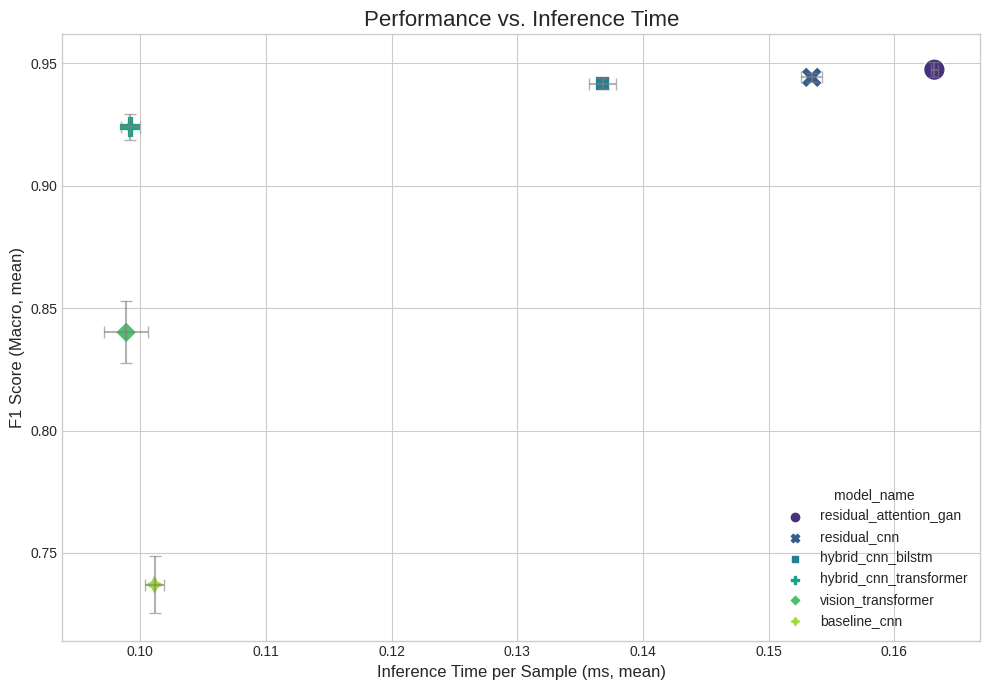

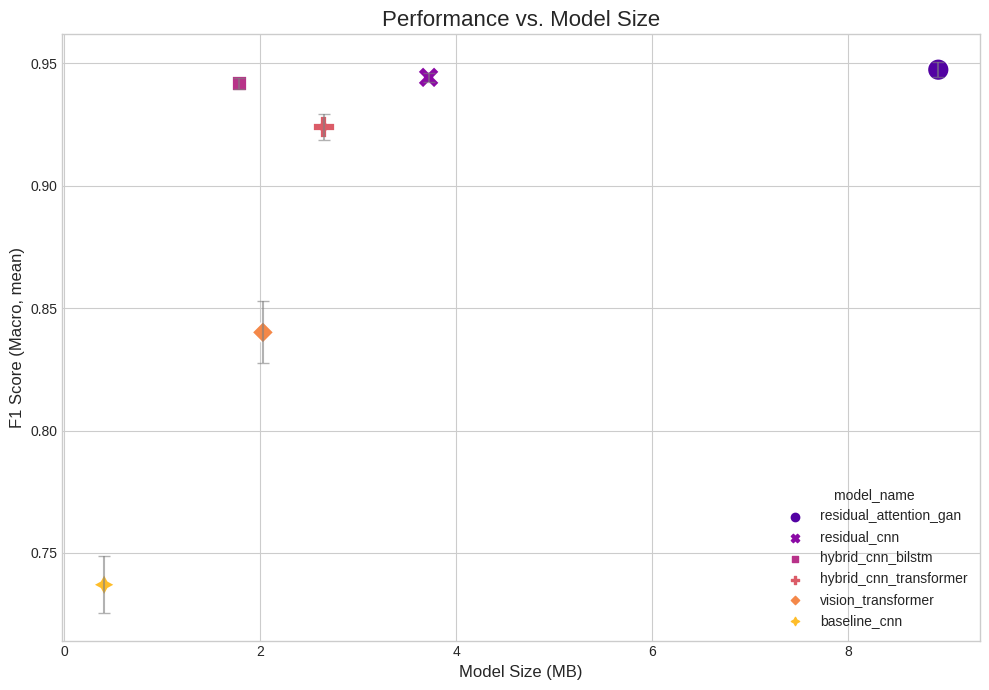


Evaluation summary saved to: /kaggle/working/evaluation_output/evaluation_summary.csv

--- Final Model Ranking ---
               model_name  test_accuracy (μ)  test_accuracy (σ)  f1_macro (μ)  \
0  residual_attention_gan           0.953657           0.002691      0.947398   
1            residual_cnn           0.950841           0.000957      0.944259   
2       hybrid_cnn_bilstm           0.947297           0.002231      0.941692   
3  hybrid_cnn_transformer           0.932152           0.005225      0.923918   
4      vision_transformer           0.850644           0.012377      0.840090   
5            baseline_cnn           0.749962           0.012560      0.736988   

   f1_macro (σ)  precision_macro (μ)  precision_macro (σ)  recall_macro (μ)  \
0      0.003182             0.948409             0.004714          0.947136   
1      0.001693             0.943822             0.002927          0.945615   
2      0.002320             0.940380             0.002270          0.943560   


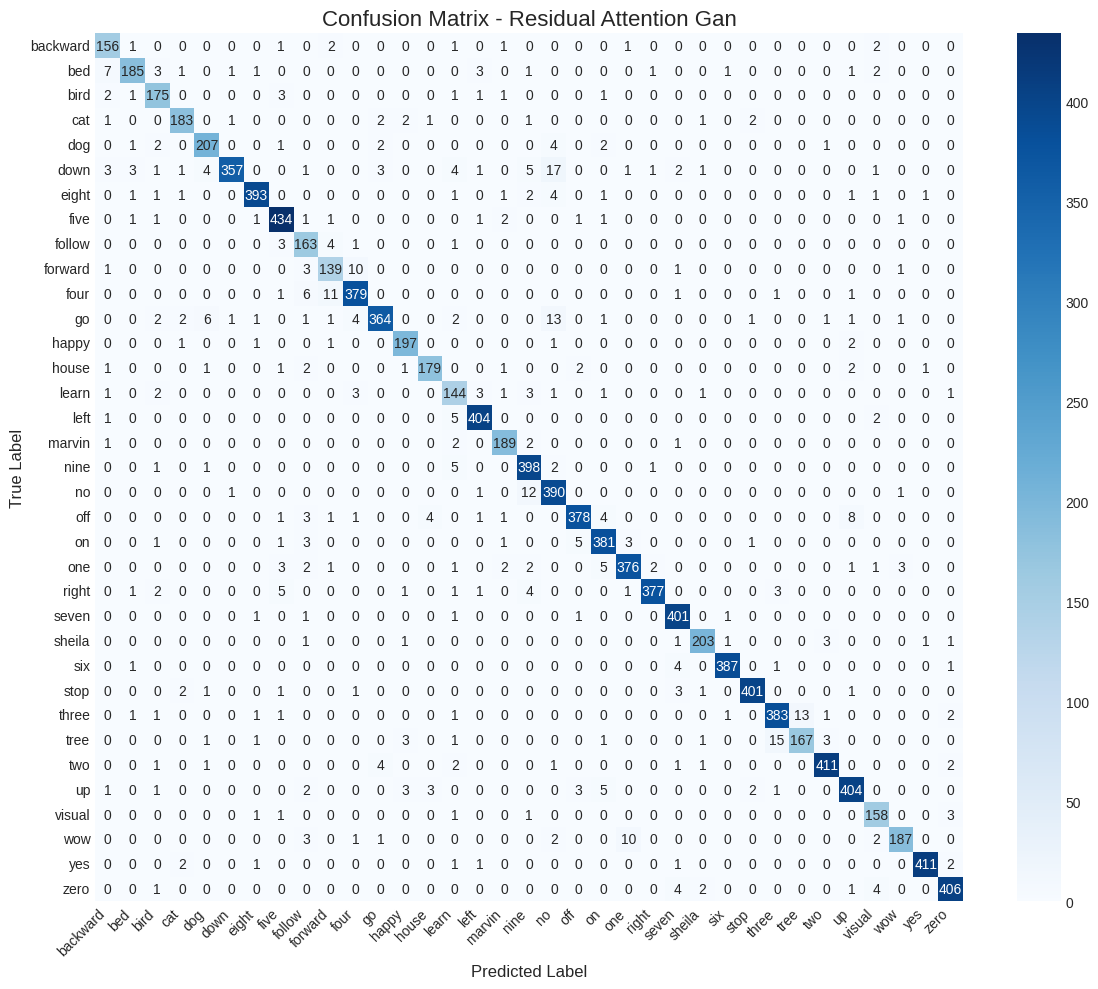

Confusion matrix saved to /kaggle/working/evaluation_output/residual_attention_gan/confusion_matrix_residual_attention_gan.png

--- Generating T-SNE plot for residual_attention_gan ---
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


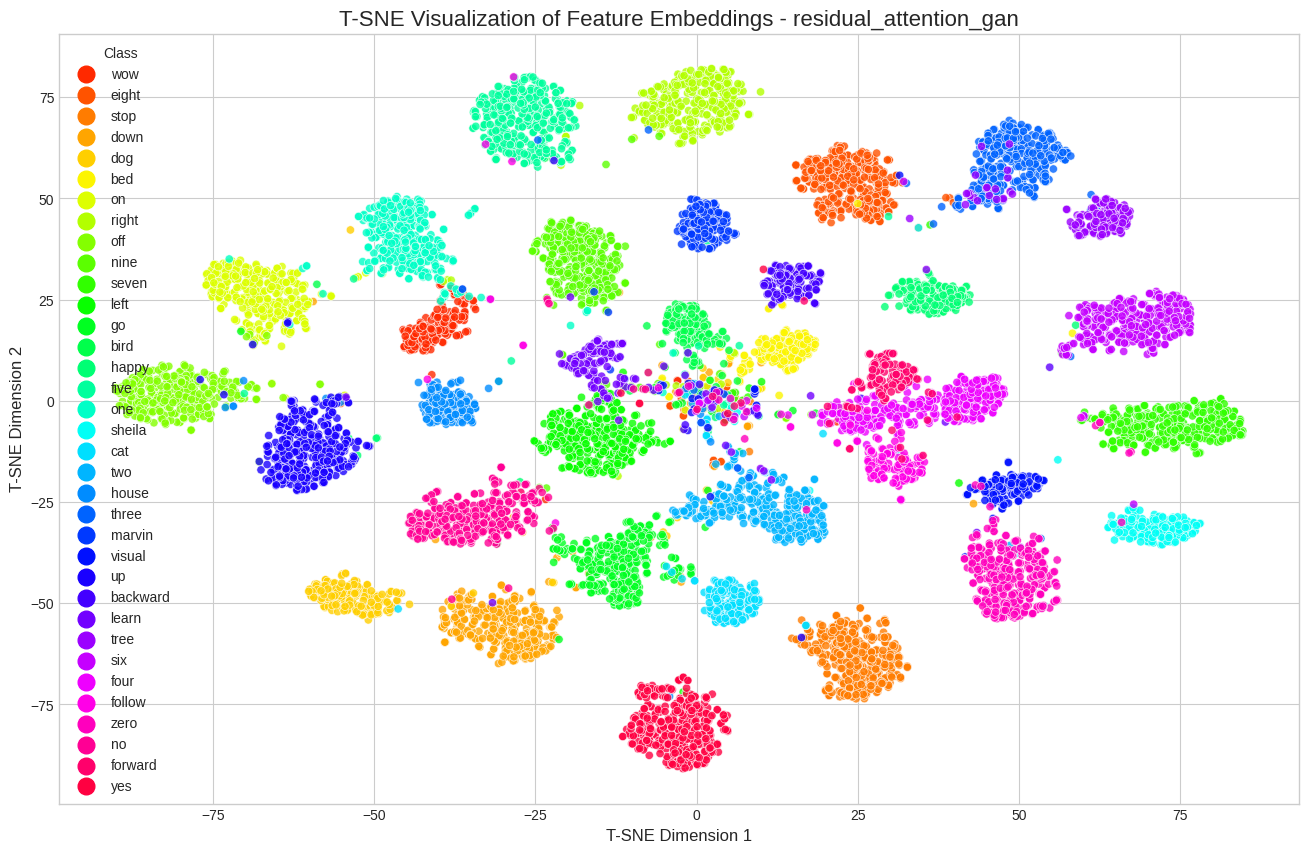

T-SNE plot saved to /kaggle/working/evaluation_output/residual_attention_gan/tsne_visualization_residual_attention_gan.png

--- Generating error analysis plots for residual_attention_gan ---


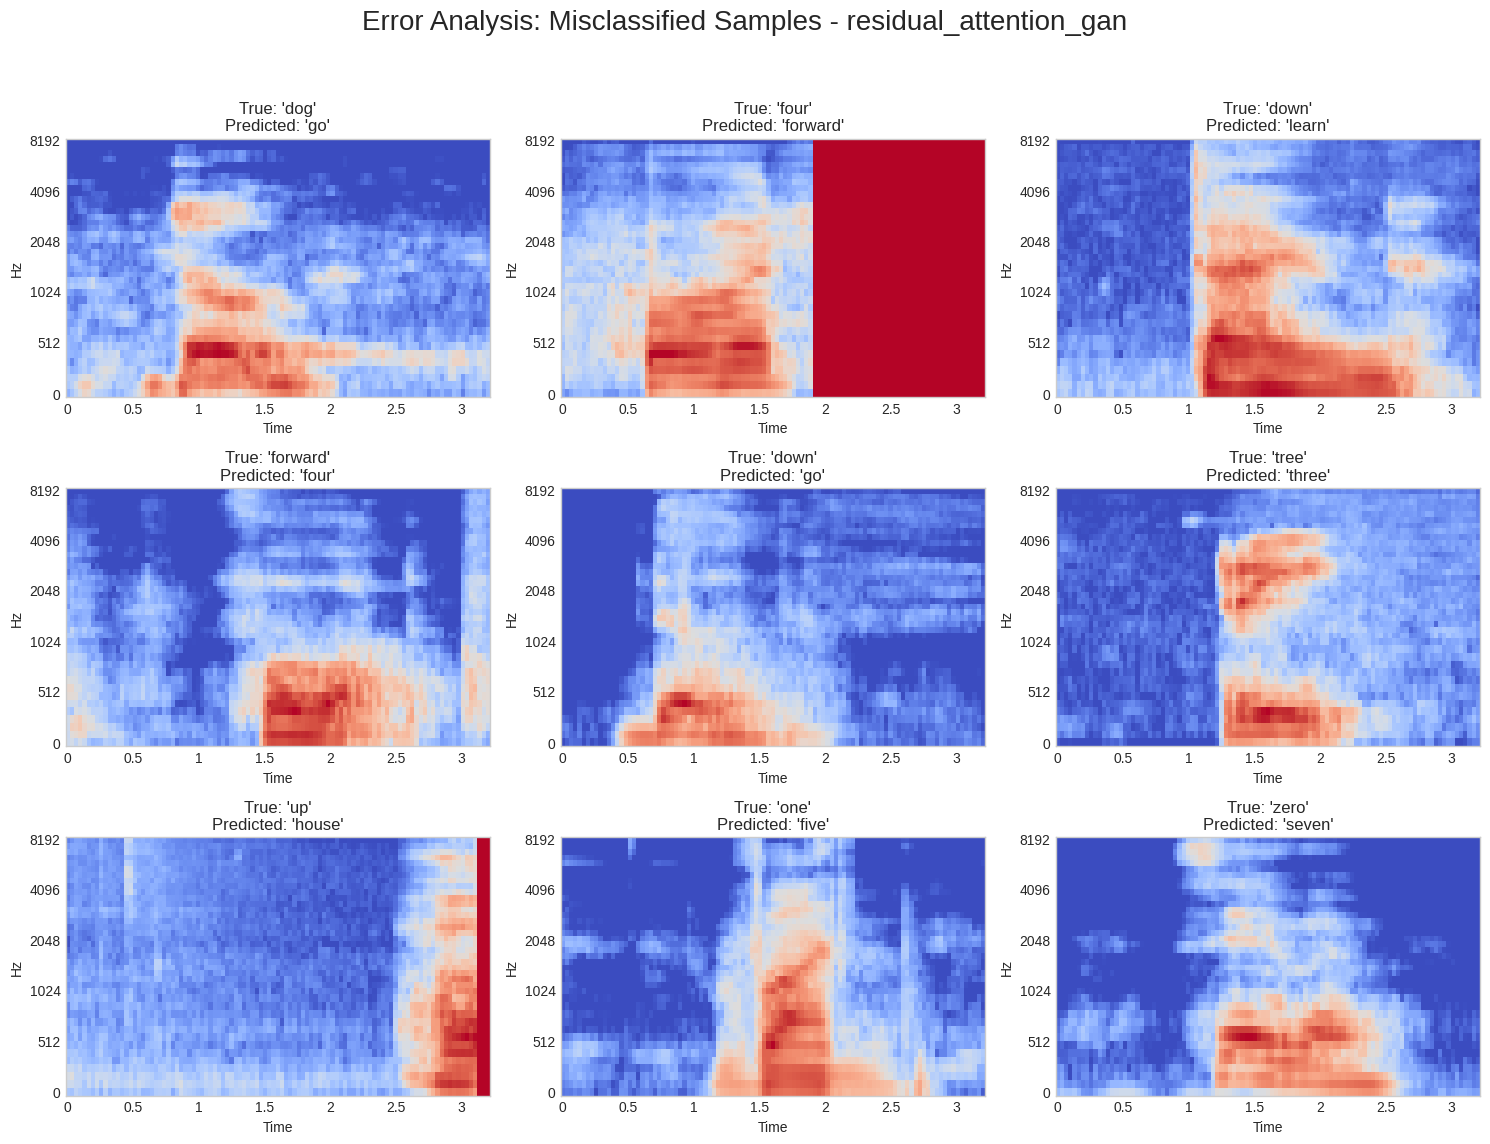

Error analysis plot saved to /kaggle/working/evaluation_output/residual_attention_gan/error_analysis_residual_attention_gan.png


In [53]:
evaluator = evaluate_and_compare_models()

best_model_path, best_model_name = run_final_analysis(evaluator)

# Model Conversion to TFLite


In [54]:
print(f"\n--- Converting selected model ({best_model_name}) to TFLite ---")
# Load the Keras model
model = tf.keras.models.load_model(best_model_path)

# Create a TensorFlow Lite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Default optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model to .tflite
tflite_model = converter.convert()

# Save the .tflite file
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

print(f"Model '{best_model_name}' converted successfully to model.tflite")


--- Converting selected model (residual_attention_gan) to TFLite ---
Saved artifact at '/tmp/tmpxk54ty3l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 101, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 35), dtype=tf.float32, name=None)
Captures:
  138435079936272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079939344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079938384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079936848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079935312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079937616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079938768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079938192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079937232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138435079939536

W0000 00:00:1755682184.524557      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1755682184.524616      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1755682184.569297      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
